# Experiment 3: Projectile Motion

**Team name:** REPLACE WITH TEAM NAME  
**Team members:** REPLACE WITH ALL TEAM MEMBER NAMES  
**Lab dates:** September 21 and September 28, 2026

## Objectives

By the end of this experiment, your team should be able to:

- determine a ball launcher's initial speed from a vertical launch;
- use a physical model to predict horizontal and angled-shot ranges;
- propagate measurement uncertainties and use repeated trials to estimate random uncertainty;
- compare predictions and measurements quantitatively; and
- explain whether differences are consistent with uncertainty or indicate a systematic effect.

## Before collecting data

1. Read the safety rules and the complete procedure for the shot you are about to perform.
2. Assign roles: launcher operator, catcher/paper operator, measurer, and notebook/data recorder. Rotate roles.
3. Record every measurement in SI units and keep all raw trials. Do not type only averages into the notebook.
4. Replace every example value in the code cells with your team's measurements.

> **Submission:** One notebook is submitted per team through Scholar. Each person also submits the private Individual Team Effort Report. Do not put individual reports in the public GitHub repository.


# Safety and apparatus

The spring launcher can send a steel ball fast enough to injure someone.

- Wear safety glasses whenever the launcher is in use.
- Never look into the barrel or place a hand over it.
- Keep the launcher unloaded while measuring or adjusting the apparatus.
- Announce **"firing"** and wait until everyone is clear before every shot.
- For vertical shots, one person holds the clear catch tube/shield in place and everyone else stands back.
- For horizontal and angled shots, verify that the catcher, paper, and carbon paper are secure before loading.
- Use the same spring setting for the entire experiment. If it changes, repeat the muzzle-speed measurement.

**Apparatus:** projectile launcher and steel ball, ramrod, plumb line, meterstick/tape measure, clear vertical catch tube, wooden catcher, white paper, carbon paper, masking tape, and angle scale.


# Physical model

Neglecting air resistance, horizontal acceleration is zero and vertical acceleration is constant:

$$
x(t)=x_0+v_0\cos\theta\,t,
\qquad
y(t)=y_0+v_0\sin\theta\,t-\frac12gt^2.
$$

Here $v_0$ is the launch speed, $\theta$ is measured above horizontal, and $g=9.805\ \mathrm{m/s^2}$ in Newport News.

## Vertical launch

For a vertical shot that rises a height $h_v$ above the launch point, the speed is zero at the top:

$$
v_0=\sqrt{2gh_v}.
$$

## Horizontal launch

If the ball lands a vertical distance $h$ below the launch point,

$$
t_f=\sqrt{\frac{2h}{g}},
\qquad
R_0=v_0t_f.
$$

## Angled launch

For a launch angle $\theta$ and a landing point $h$ below the launch point,

$$
R_\theta=\frac{v_0\cos\theta}{g}
\left(v_0\sin\theta+\sqrt{(v_0\sin\theta)^2+2gh}\right).
$$

Write down the assumptions behind these equations. During the conclusion, revisit whether the apparatus satisfied them.


# Uncertainty plan

Use instrument resolution for single measurements and the spread of repeated measurements for repeated trials.

- For repeated values $q_i$, report the mean $\bar q$, sample standard deviation $s_q$, and standard error $s_q/\sqrt{N}$.
- For a predicted value calculated from several measured inputs, this notebook uses Monte Carlo propagation. Each input is sampled from a normal distribution with the measured value as its mean and its uncertainty as its standard deviation.
- Compare prediction $A\pm\delta A$ and measurement $B\pm\delta B$ with

$$
z=\frac{|A-B|}{\sqrt{\delta A^2+\delta B^2}}.
$$

As a practical guide, $z\lesssim2$ is consistent within combined uncertainty. A larger value deserves a physical explanation; it is not something to hide by deleting trials.

Before taking data, record the meterstick resolution, the angle-scale resolution, and how you will define the launch point and impact point.


In [1]:
# Imports and analysis helpers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

g = 9.79906      # m/s^2, local gravitational acceleration
delta_g = 0.005   # m/s^2
rng = np.random.default_rng(201)

def repeated_summary(values, unit=""):
    values = np.asarray(values, dtype=float)
    if values.size < 2:
        raise ValueError("Enter at least two repeated measurements.")
    mean = values.mean()
    sd = values.std(ddof=1)
    sem = sd / np.sqrt(values.size)
    print(f"N = {values.size}")
    print(f"mean = {mean:.5g} {unit}")
    print(f"sample SD = {sd:.3g} {unit}")
    print(f"standard error = {sem:.3g} {unit}")
    return mean, sd, sem

def compatibility_z(a, da, b, db):
    return abs(a-b) / np.hypot(da, db)


# Part I — Determine the launch speed with vertical shots

## Original apparatus diagram

<img src="./images/vertical_launch_configuration.png" alt="Vertical launch configuration" width="260">

*Figure 1. Vertical-launch configuration used to determine the launch speed.*

## Setup

1. Clamp the launcher securely with the barrel vertical. Confirm the angle scale reads $90^\circ$.
2. Identify a reproducible reference point for the ball at release (for example, the center of the ball at the muzzle). Mark this definition in your notes.
3. Place the clear catch tube/shield above the launcher. Keep faces and hands away from the flight path.
4. Select one spring setting and record it. Use this same setting for every later shot.
5. Fire one test shot to verify the ball remains inside the protected region. Do not measure this test shot.

## Data collection

For at least five trials, measure the maximum vertical rise from the launch reference to the top of the ball's trajectory. The observer should view the scale at eye level to reduce parallax. Record all trials, including a visibly poor shot, and annotate what happened instead of silently deleting it.

### Quality checkpoint

Before moving on, calculate the spread. If the range of the trials is much larger than the ruler resolution, check the launcher setting, release method, vertical alignment, and parallax. Repeat the complete set only after identifying a cause.


In [10]:
# Vertical-shot raw data — REPLACE with your measurements in meters
vertical_height_m = np.array([1.18, 1.20, 1.19, 1.21, 1.18])
delta_vertical_height = 0.005  # m; justify from scale resolution and reading method

vertical_table = pd.DataFrame({
    "trial": np.arange(1, len(vertical_height_m)+1),
    "vertical rise (m)": vertical_height_m,
})
display(vertical_table)
h_v, s_h_v, sem_h_v = repeated_summary(vertical_height_m, "m")

# Use the larger of instrument uncertainty and standard error.
dh_v = max(delta_vertical_height, sem_h_v)
print(f"uncertainty from meterstick resolution: {delta_vertical_height:.3g} m")
print(f"uncertainty from repeated trials: {sem_h_v:.3g} m")
print(f"Adopted vertical-rise uncertainty: {dh_v:.3g} m")


,trial,vertical rise (m)
0,1,1.18
1,2,1.20
2,3,1.19
3,4,1.21
4,5,1.18


N = 5
mean = 1.192 m
sample SD = 0.013 m
standard error = 0.00583 m
uncertainty from meterstick resolution: 0.005 m
uncertainty from repeated trials: 0.00583 m
Adopted vertical-rise uncertainty: 0.00583 m


In [11]:
# Launch speed and propagated uncertainty
v0_vertical = np.sqrt(2*g*h_v)
dv0_vertical = 0.5*v0_vertical*np.sqrt((delta_g/g)**2 + (dh_v/h_v)**2)

print(f"Launch speed from vertical shots: {v0_vertical:.4f} ± {dv0_vertical:.4f} m/s")


Launch speed from vertical shots: 4.8333 ± 0.0119 m/s


## Part I interpretation

In the markdown cell below, answer these questions before continuing:

- Is the trial-to-trial spread larger or smaller than the meterstick reading uncertainty?
- Which uncertainty did the code adopt, and why?
- What feature of the vertical-shot method is most likely to produce a systematic error?


**Team response:** REPLACE WITH YOUR INTERPRETATION.


# Part II — Horizontal prediction and verification

## Original apparatus diagram

<img src="./images/horizontal_launch_configuration.png" alt="Horizontal launch configuration" width="260">

*Figure 2. Horizontal-launch configuration for predicting and measuring the range.*

## Geometry

1. Rotate the unloaded launcher to $0^\circ$ and verify that it is level.
2. Hang a plumb line from the center of the muzzle and mark the point directly below it on the floor/table. This is $x=0$.
3. Measure the vertical distance $h$ from the **center of the ball at launch** to the height of the paper in the catcher. Measure twice, preferably by two people.
4. Enter $h$, its uncertainty, and the vertical-shot launch speed below.
5. Run the prediction cell before placing the catcher. Record the prediction independently of the measured impacts.


In [13]:
# Horizontal-shot geometry — REPLACE with your measurements
h_horizontal = 1.025       # m, launch point to impact plane
dh_horizontal = 0.005      # m

t_horizontal = np.sqrt(2*h_horizontal/g)
R_horizontal_pred = v0_vertical*t_horizontal

# Monte Carlo propagation
n_mc = 200000
v_draw = rng.normal(v0_vertical, dv0_vertical, n_mc)
h_draw = rng.normal(h_horizontal, dh_horizontal, n_mc)
g_draw = rng.normal(g, delta_g, n_mc)
R_draw = v_draw*np.sqrt(2*h_draw/g_draw)
dR_horizontal_pred = R_draw.std(ddof=1)

print(f"Predicted horizontal flight time: {t_horizontal:.4f} s")
print(f"Predicted horizontal range: {R_horizontal_pred:.4f} ± {dR_horizontal_pred:.4f} m")


Predicted horizontal flight time: 0.4574 s
Predicted horizontal range: 2.2107 ± 0.0077 m


## Horizontal-shot data collection

1. Place the center of the catcher at the predicted range. Tape white paper to it and place carbon paper on top, carbon side down.
2. Make one test shot. Confirm the mark is well inside the paper; move the catcher only if necessary, and record that adjustment.
3. Make at least five measured shots without changing the launcher or spring setting.
4. Measure each impact's horizontal distance from the plumb-line origin. Use a consistent definition of the impact point (for example, the center of the mark).
5. If a trial is rejected, keep it in the raw table and state an objective reason.


In [5]:
# Horizontal-shot raw data — REPLACE with your measurements in meters
horizontal_range_m = np.array([1.545, 1.552, 1.548, 1.559, 1.550])
delta_horizontal_range = 0.005  # m

horizontal_table = pd.DataFrame({
    "trial": np.arange(1, len(horizontal_range_m)+1),
    "horizontal range (m)": horizontal_range_m,
})
display(horizontal_table)
R_horizontal_meas, s_Rh, sem_Rh = repeated_summary(horizontal_range_m, "m")
dR_horizontal_meas = max(delta_horizontal_range, sem_Rh)

z_horizontal = compatibility_z(
    R_horizontal_pred, dR_horizontal_pred,
    R_horizontal_meas, dR_horizontal_meas,
)

# Independent launch-speed estimate from the measured horizontal range
v0_horizontal = R_horizontal_meas / t_horizontal
dv0_horizontal = v0_horizontal*np.sqrt(
    (dR_horizontal_meas/R_horizontal_meas)**2
    + 0.25*(dh_horizontal/h_horizontal)**2
    + 0.25*(delta_g/g)**2
)

print(f"Measured horizontal range: {R_horizontal_meas:.4f} ± {dR_horizontal_meas:.4f} m")
print(f"Prediction-measurement compatibility: z = {z_horizontal:.2f}")
print(f"Launch speed from horizontal shots: {v0_horizontal:.4f} ± {dv0_horizontal:.4f} m/s")


,trial,horizontal range (m)
0,1,1.545
1,2,1.552
2,3,1.548
3,4,1.559
4,5,1.550


N = 5
mean = 1.5508 m
sample SD = 0.00526 m
standard error = 0.00235 m
Measured horizontal range: 1.5508 ± 0.0050 m
Prediction-measurement compatibility: z = 72.01
Launch speed from horizontal shots: 3.3906 ± 0.0137 m/s


## Horizontal-shot checkpoint

Explain whether the prediction and measurement agree within combined uncertainty. Compare the two independent launch-speed estimates as well. If $z>2$, inspect the apparatus before proceeding: confirm the angle is truly horizontal, the height uses the ball center at launch, the plumb-line origin has not moved, and the spring setting is unchanged. Document any correction and rerun the prediction before collecting replacement trials.


**Team response:** REPLACE WITH YOUR QUANTITATIVE COMPARISON.


# Part III — Angled prediction and verification

## Original apparatus diagram

<img src="./images/launcher_at_30_degrees.png" alt="Launcher set to 30 degrees" width="260">

*Figure 3. Angled-launch configuration, shown at 30 degrees.*

1. Choose an angle between $20^\circ$ and $45^\circ$, unless your instructor specifies one. Record the angle and scale resolution.
2. Keep the same spring setting. Measure the vertical distance from the ball center at launch to the impact plane again; rotating the launcher can change the launch-point height.
3. Enter the geometry below and compute the prediction before moving the catcher.
4. Place the catcher at the predicted range, make one test shot, then collect at least five measured shots.
5. Do not reuse the horizontal height automatically. A few millimeters matter in the prediction.


In [6]:
# Angled-shot geometry — REPLACE with your measurements
theta_deg = 30.0
dtheta_deg = 0.5
h_angled = 1.015       # m, launch point above impact plane
dh_angled = 0.005      # m

theta = np.deg2rad(theta_deg)
R_angled_pred = (v0_vertical*np.cos(theta)/g) * (
    v0_vertical*np.sin(theta)
    + np.sqrt((v0_vertical*np.sin(theta))**2 + 2*g*h_angled)
)

v_draw = rng.normal(v0_vertical, dv0_vertical, n_mc)
theta_draw = rng.normal(np.deg2rad(theta_deg), np.deg2rad(dtheta_deg), n_mc)
h_draw = rng.normal(h_angled, dh_angled, n_mc)
g_draw = rng.normal(g, delta_g, n_mc)
R_angle_draw = (v_draw*np.cos(theta_draw)/g_draw) * (
    v_draw*np.sin(theta_draw)
    + np.sqrt((v_draw*np.sin(theta_draw))**2 + 2*g_draw*h_draw)
)
dR_angled_pred = R_angle_draw.std(ddof=1)

print(f"Predicted range at {theta_deg:.1f}°: {R_angled_pred:.4f} ± {dR_angled_pred:.4f} m")


Predicted range at 30.0°: 3.1992 ± 0.0142 m


In [7]:
# Angled-shot raw data — REPLACE with your measurements in meters
angled_range_m = np.array([2.36, 2.35, 2.37, 2.36, 2.34])
delta_angled_range = 0.005  # m

angled_table = pd.DataFrame({
    "trial": np.arange(1, len(angled_range_m)+1),
    "angled range (m)": angled_range_m,
})
display(angled_table)
R_angled_meas, s_Ra, sem_Ra = repeated_summary(angled_range_m, "m")
dR_angled_meas = max(delta_angled_range, sem_Ra)
z_angled = compatibility_z(R_angled_pred, dR_angled_pred, R_angled_meas, dR_angled_meas)

print(f"Measured angled range: {R_angled_meas:.4f} ± {dR_angled_meas:.4f} m")
print(f"Prediction-measurement compatibility: z = {z_angled:.2f}")


,trial,angled range (m)
0,1,2.36
1,2,2.35
2,3,2.37
3,4,2.36
4,5,2.34


N = 5
mean = 2.356 m
sample SD = 0.0114 m
standard error = 0.0051 m
Measured angled range: 2.3560 ± 0.0051 m
Prediction-measurement compatibility: z = 55.93


,configuration,predicted range (m),prediction uncertainty (m),measured range (m),measurement uncertainty (m),compatibility z
0,horizontal,2.210701,0.007680,1.5508,0.005000,72.009819
1,30.0° angled,3.199164,0.014186,2.3560,0.005099,55.933622


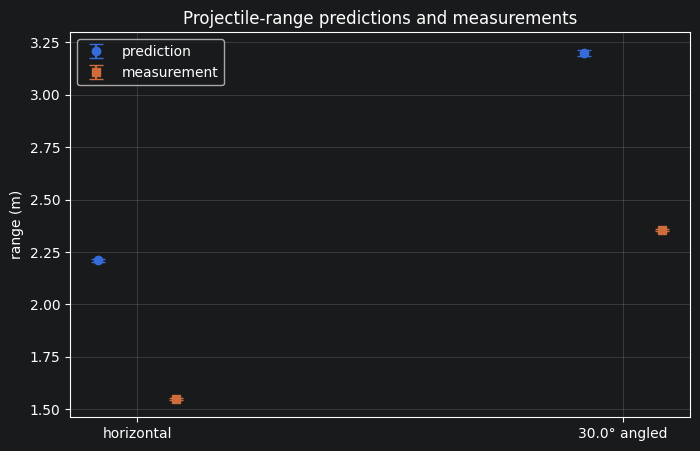

In [8]:
# Summary figure and comparison table
comparison = pd.DataFrame({
    "configuration": ["horizontal", f"{theta_deg:.1f}° angled"],
    "predicted range (m)": [R_horizontal_pred, R_angled_pred],
    "prediction uncertainty (m)": [dR_horizontal_pred, dR_angled_pred],
    "measured range (m)": [R_horizontal_meas, R_angled_meas],
    "measurement uncertainty (m)": [dR_horizontal_meas, dR_angled_meas],
    "compatibility z": [z_horizontal, z_angled],
})
display(comparison)

x = np.arange(2)
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(x-0.08, comparison["predicted range (m)"],
            yerr=comparison["prediction uncertainty (m)"],
            fmt="o", capsize=5, label="prediction")
ax.errorbar(x+0.08, comparison["measured range (m)"],
            yerr=comparison["measurement uncertainty (m)"],
            fmt="s", capsize=5, label="measurement")
ax.set_xticks(x, comparison["configuration"])
ax.set_ylabel("range (m)")
ax.set_title("Projectile-range predictions and measurements")
ax.grid(alpha=0.3)
ax.legend()
plt.show()


# Your lab report

Replace the prompts below with a coherent scientific report. Do not leave instructional text or example values in the submitted notebook.

## Experimental procedure

Describe what your team actually did, in complete paragraphs. Include:

- launcher mounting, spring setting, and safety checks;
- the reference points used for vertical height, horizontal origin, and impact location;
- how uncertainties were assigned;
- how the vertical, horizontal, and angled trials were collected; and
- any troubleshooting, rejected trials, or apparatus changes.

## Data and analysis

Present labeled raw-data tables and report, with units and uncertainties:

- vertical rise and the launch speed obtained from it;
- horizontal-shot height, predicted range, measured range, and independent launch-speed estimate;
- angled-shot angle and height, predicted range, and measured range; and
- both compatibility $z$ values.

Every figure needs a figure number, descriptive caption, labeled axes, and units. Explain why standard error or instrument resolution was used for each final measured uncertainty.

## Results and conclusion

Your conclusion should answer the physical question, not merely say that the experiment “worked.”

1. Compare predicted and measured ranges numerically for both configurations.
2. Interpret each compatibility $z$ value.
3. Compare the launch speeds obtained by the vertical and horizontal methods.
4. Identify the dominant random uncertainty and the most plausible systematic error.
5. Explain whether air resistance, angle alignment, reference-point choice, or launcher repeatability could account for the observed differences.
6. State one specific improvement that would most reduce uncertainty or bias.


# Submission checklist

Before the team submits:

- [ ] Replace the team-identification placeholders.
- [ ] Replace every example measurement and uncertainty with team data.
- [ ] Run **Runtime → Run all** in Colab (or **Kernel → Restart & Run All** in Jupyter).
- [ ] Confirm that every code cell runs without an error and every table/figure is visible.
- [ ] Confirm units, significant figures, captions, and uncertainty notation.
- [ ] Remove unused code and all “REPLACE” prompts.
- [ ] Save the completed notebook to the team's GitHub repository with a descriptive commit message.
- [ ] Download the final `.ipynb` from GitHub and submit that same file to **Lab 3 — Team Notebook Submission** in Scholar.
- [ ] Each student privately submits the Individual Team Effort Report in Scholar.

The GitHub and Scholar notebook copies should be identical. One designated team member should verify both uploads before leaving the submission page.
